In [1]:
import os
import random
from shutil import copyfile

def get_class_distribution(directory):
    class_folders = os.listdir(directory)
    class_distribution = {}
    
    for class_folder in class_folders:
        class_path = os.path.join(directory, class_folder)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_distribution[class_folder] = num_images
    
    return class_distribution

def balance_dataset(directory):
    class_folders = os.listdir(directory)
    max_class_size = 0
    
   
    for class_folder in class_folders:
        class_path = os.path.join(directory, class_folder)
        if os.path.isdir(class_path):
            class_size = len(os.listdir(class_path))
            max_class_size = max(max_class_size, class_size)
    
 
    oversampled_images = []
    
    for class_folder in class_folders:
        class_path = os.path.join(directory, class_folder)
        if os.path.isdir(class_path):
            class_size = len(os.listdir(class_path))
            oversampling_factor = max_class_size - class_size
            
            
            if oversampling_factor <= 0:
                continue
            
            # Creating  new copies of images 
            file_names = os.listdir(class_path)
            for i in range(oversampling_factor):
                source_file = os.path.join(class_path, random.choice(file_names))
                target_file = os.path.join(class_path, f"copy_{i}.jpg")  
                copyfile(source_file, target_file)
                oversampled_images.append(target_file)
    
    return oversampled_images


dataset_directory = "image"


class_distribution_before = get_class_distribution(dataset_directory)
print("Class Distribution before balancing:")
for class_folder, num_images in class_distribution_before.items():
    print(f"{class_folder}: {num_images} images")

oversampled_images = balance_dataset(dataset_directory)

class_distribution_after = get_class_distribution(dataset_directory)
print("\nClass Distribution after balancing:")
for class_folder, num_images in class_distribution_after.items():
    print(f"{class_folder}: {num_images} images")


print("\nOversampled images:")
for image_file in oversampled_images:
    print(image_file)


Class Distribution before balancing:
black_pod_rot: 618 images
healthy: 618 images
healthy_borer: 618 images
pod_borer: 618 images

Class Distribution after balancing:
black_pod_rot: 618 images
healthy: 618 images
healthy_borer: 618 images
pod_borer: 618 images

Oversampled images:


In [2]:
pip install pillow


   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.6 MB 3.3 MB/s eta 0:00:01
   ----------------------- ---------------- 1.6/2.6 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 4.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
from PIL import Image

def resize_images(directory, output_directory, target_size):
    os.makedirs(output_directory, exist_ok=True)
    
    for class_folder in os.listdir(directory):
        class_path = os.path.join(directory, class_folder)
        if os.path.isdir(class_path):
            output_class_path = os.path.join(output_directory, class_folder)
            os.makedirs(output_class_path, exist_ok=True)
            
            for image_file in os.listdir(class_path):
                image_path = os.path.join(class_path, image_file)
                output_image_path = os.path.join(output_class_path, image_file)
                
                try:
                    with Image.open(image_path) as img:
                        original_width, original_height = img.size
                        aspect_ratio = original_width / original_height
                        
                        # Calculate target width and height
                        target_width = target_size
                        target_height = int(target_width / aspect_ratio)
                        
                        # Resize image
                        if target_height > target_size:
                            resized_img = img.resize((target_width, target_height), Image.LANCZOS)
                        else:
                            target_height = target_size
                            target_width = int(target_height * aspect_ratio)
                            resized_img = img.resize((target_width, target_height), Image.LANCZOS)
                        
                        # Create blank image
                        new_img = Image.new("RGB", (target_size, target_size), (255, 255, 255))
                        
                        # Calculate position to paste resized image
                        paste_x = int((target_size - target_width) / 2)
                        paste_y = int((target_size - target_height) / 2)
                        
                        # Paste resized image onto blank image
                        new_img.paste(resized_img, (paste_x, paste_y))
                        
                        # Save resized image
                        new_img.save(output_image_path)
                
                except Exception as e:
                    print(f"Error processing {image_path}: {e}")

# Specify directories and target size
input_directory = "image"
output_directory = "resized"
target_size = 256

# Call function to resize images
resize_images(input_directory, output_directory, target_size)


Error processing image\black_pod_rot\.DS_Store: cannot identify image file 'image\\black_pod_rot\\.DS_Store'
Error processing image\healthy\.DS_Store: cannot identify image file 'image\\healthy\\.DS_Store'


In [4]:
!pip install tensorflow

  Using cached tensorflow-2.18.0-cp310-cp310-win_amd64.whl.metadata (3.3 kB)
  Using cached tensorflow_intel-2.18.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.12.23-py2.py3-none-any.whl.metadata (876 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.3-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached keras-3.8.0-py3-none-any.whl.metadata (5.8 kB)
  Using cac

In [5]:
pip uninstall matplotlib


Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install matplotlib==3.9.0


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 23.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 31.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install scipy


  Using cached scipy-1.15.1-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.15.1-cp310-cp310-win_amd64.whl (43.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random

def augment_images(directory, output_directory, target_size, num_augmented_images):
    os.makedirs(output_directory, exist_ok=True)
    
    # Define the augmentation parameters
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )
    
    for class_folder in os.listdir(directory):
        class_path = os.path.join(directory, class_folder)
        if os.path.isdir(class_path):
            output_class_path = os.path.join(output_directory, class_folder)
            os.makedirs(output_class_path, exist_ok=True)
            
            for image_file in os.listdir(class_path):
                image_path = os.path.join(class_path, image_file)
                output_image_prefix = os.path.splitext(image_file)[0]
                
                # Load the image
                image = plt.imread(image_path)
                image = image.reshape((1,) + image.shape)  # Reshape to match the input shape for the generator
                
                # Generate augmented images
                i = 0
                for batch in datagen.flow(image, batch_size=1, save_to_dir=output_class_path,
                                          save_prefix=output_image_prefix, save_format='jpg'):
                    i += 1
                    if i >= num_augmented_images:
                        break

# Specify the directory path where your original images are located
input_directory = "resized"

# Specify the directory path where you want to save the augmented images
output_directory = "augmented"

target_size = (256, 256)

# Specify the number of augmented images to generate per original image
num_augmented_images = 5

# Call the function to perform data augmentation
augment_images(input_directory, output_directory, target_size, num_augmented_images)


Matplotlib is building the font cache; this may take a moment.


In [9]:
import matplotlib
print(matplotlib.__version__)
import sys
print(sys.version)

3.9.0
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


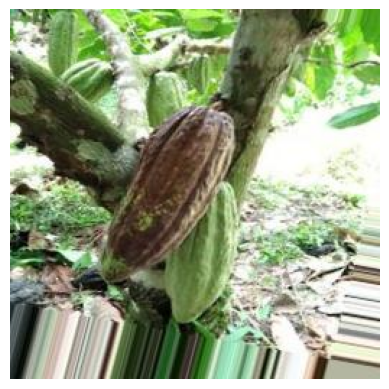

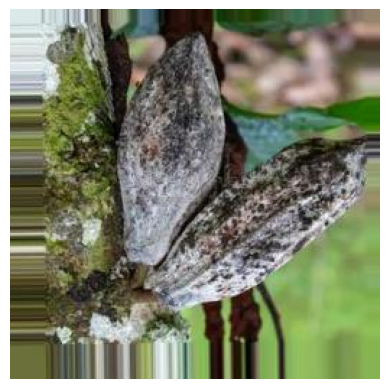

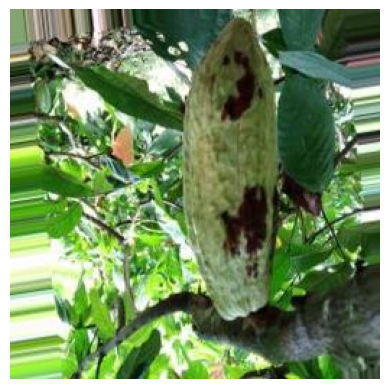

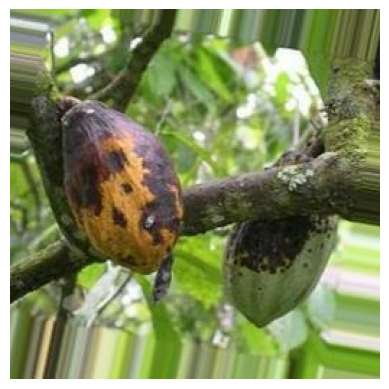

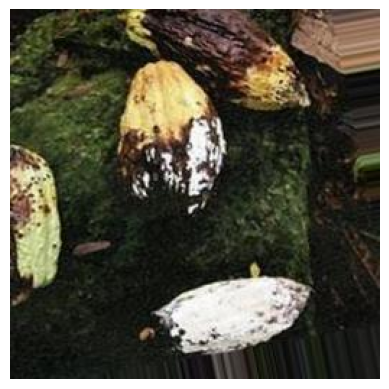

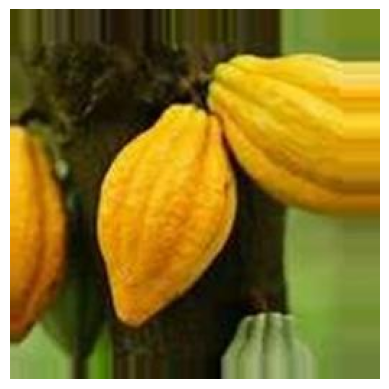

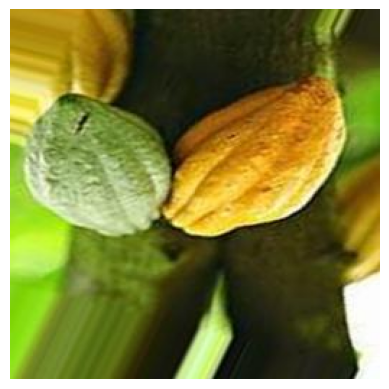

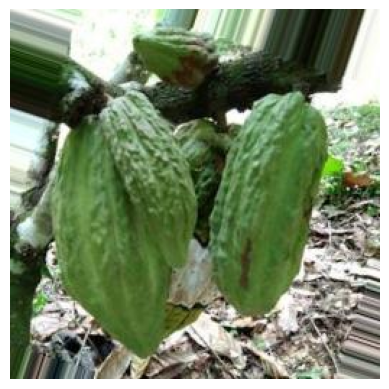

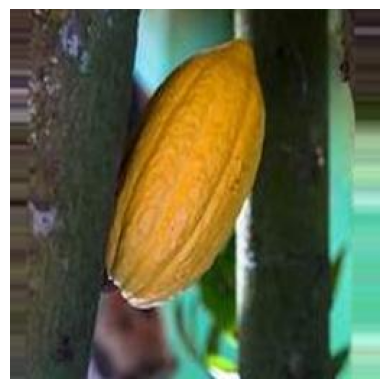

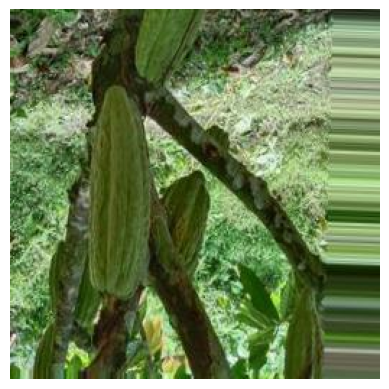

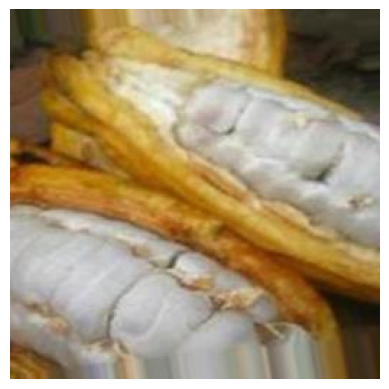

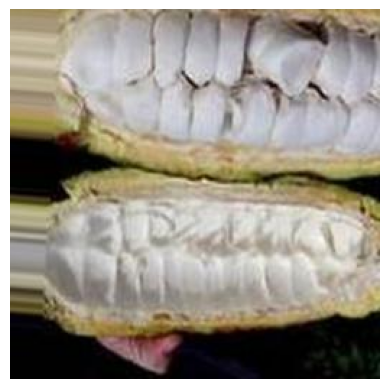

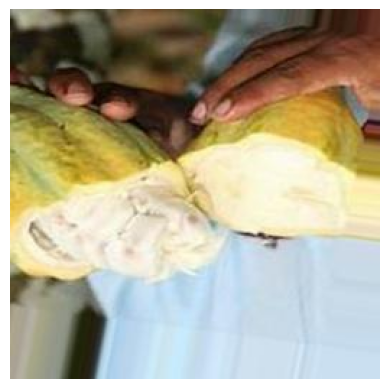

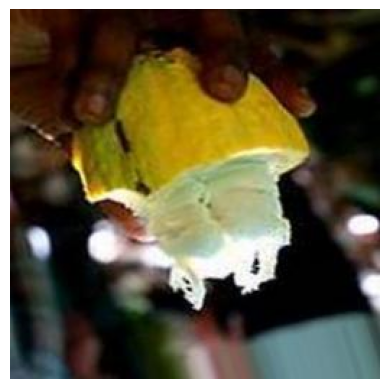

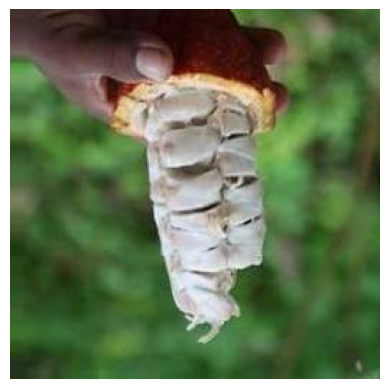

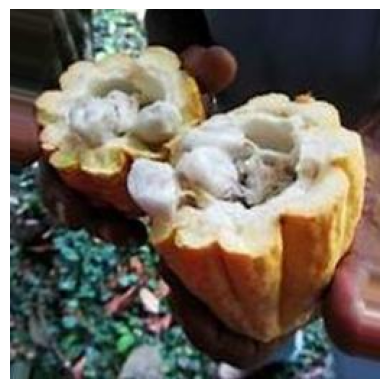

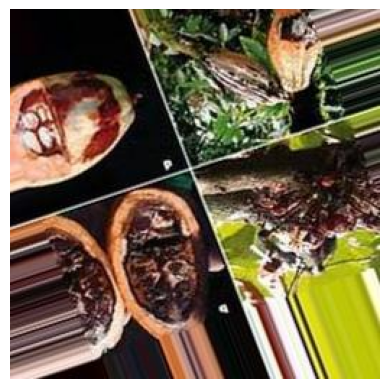

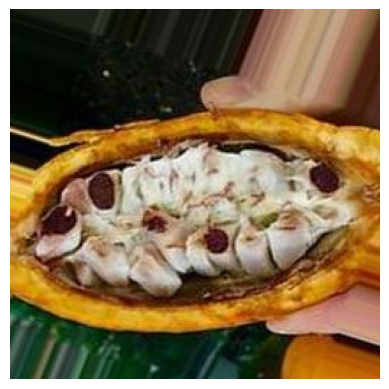

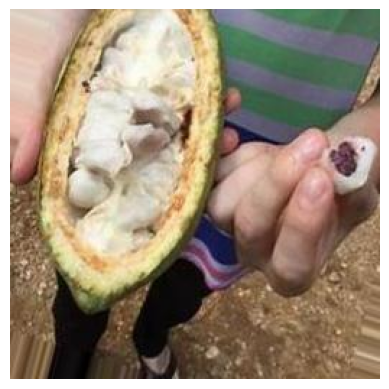

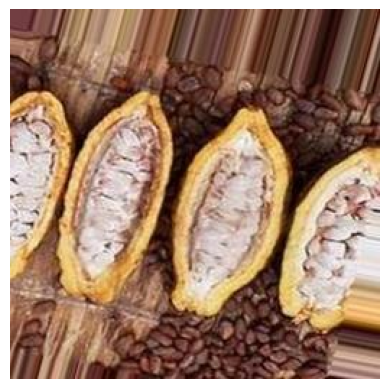

In [10]:
import os
import matplotlib.pyplot as plt

# Specify the directory path where your augmented images are located
augmented_directory = "augmented"

# Specify the number of images to display
num_images_to_display = 5

# Display the augmented images
for class_folder in os.listdir(augmented_directory):
    class_path = os.path.join(augmented_directory, class_folder)
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        random.shuffle(image_files)
        for i in range(num_images_to_display):
            image_path = os.path.join(class_path, image_files[i])
            image = plt.imread(image_path)
            plt.imshow(image)
            plt.axis('off')
            plt.show()


In [1]:
import os
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Specify the directory path where your augmented images are located
train_directory = "augmented"

# Specify the target size for the input images
target_size = (256, 256)

# Specify the number of classes
num_classes = 4

# Define the CNN model
model = Sequential()

model.add(Input(shape=(target_size[0], target_size[1], 3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Specify the batch size and number of training epochs
batch_size = 32
epochs = 10

# Perform data augmentation on the training images
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=True,
                                   fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
        train_directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical')

# Calculate steps_per_epoch
steps_per_epoch = train_generator.samples // batch_size

# Train the model
model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs)

# Save the trained model
model.save('cocoa_disease_model.h5')


Found 37060 images belonging to 4 classes.


c:\Test\cocoa-disease\cocoa-disease\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 1047s 901ms/step - accuracy: 0.7280 - loss: 0.7255
Epoch 2/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 1s 15us/step - accuracy: 0.8750 - loss: 0.3631    
Epoch 3/10


c:\Test\cocoa-disease\cocoa-disease\.venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1158/1158 ━━━━━━━━━━━━━━━━━━━━ 760s 656ms/step - accuracy: 0.8729 - loss: 0.3515
Epoch 4/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 1s 9us/step - accuracy: 0.8125 - loss: 0.5682     
Epoch 5/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 755s 652ms/step - accuracy: 0.9039 - loss: 0.2653
Epoch 6/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 1s 8us/step - accuracy: 0.9062 - loss: 0.1760     
Epoch 7/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 756s 653ms/step - accuracy: 0.9119 - loss: 0.2423
Epoch 8/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 1s 8us/step - accuracy: 0.9375 - loss: 0.2264     
Epoch 9/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 753s 650ms/step - accuracy: 0.9230 - loss: 0.2108
Epoch 10/10
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 1s 7us/step - accuracy: 0.9062 - loss: 0.1955     


In [2]:
import os
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Specify the directory path where your test images are located
test_directory = "augmented"

# Specify the target size for the input images
target_size = (256, 256)

# Load the trained model
model = load_model('cocoa_disease_model.h5')

# Perform data normalization on the test images
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
        test_directory,
        target_size=target_size,
        batch_size=1,
        class_mode='categorical',
        shuffle=False)

# Evaluate the model on the test images
scores = model.evaluate(test_generator, steps=test_generator.samples)

# Print the test accuracy
print(f"Test Accuracy: {scores[1]*100:.2f}%")


Found 37060 images belonging to 4 classes.


c:\Test\cocoa-disease\cocoa-disease\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


37060/37060 ━━━━━━━━━━━━━━━━━━━━ 366s 10ms/step - accuracy: 0.9599 - loss: 0.1206
Test Accuracy: 96.57%
